# EDA: Diabetes 130-US Hospitals for Years 1999-2008

Analisis exploratorio de datos (EDA) del dataset de reingresos hospitalarios de pacientes diabeticos,
obtenido del UCI Machine Learning Repository (id=296).

Contiene 101,766 encuentros hospitalarios y 47 variables (demograficas, clinicas y de medicacion),
mas la variable objetivo `readmitted` (si el paciente fue readmitido: `NO`, `>30` dias, `<30` dias).

https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

## 1. Carga de librerias y del dataset

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_validate

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

In [3]:
# Carga del dataset desde archivo local
df = pd.read_csv(
    "datos/diabetic_data.csv",
    na_values=["?"]
)

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


> **Código.** Cargamos el dataset desde una copia local del archivo CSV original de UCI mediante pd.read_csv(). El archivo contiene las variables predictoras, la variable objetivo readmitted y los identificadores encounter_id y patient_nbr, por lo que se cargan directamente en un único DataFrame df.

> **Por qué.** Utilizar una copia local permite que el notebook pueda ejecutarse completamente sin depender de conexión a Internet ni de paquetes adicionales como ucimlrepo. Para mantener la reproducibilidad, el archivo CSV utilizado se incluye junto con el proyecto y se carga mediante una ruta relativa. La documentación y el diccionario de variables de UCI se utilizaron como referencia para interpretar correctamente las columnas.

>**Qué descubrimos.**

> - El archivo contiene 101,766 encuentros hospitalarios. La variable objetivo es readmitted. La unidad de análisis es el encuentro hospitalario, no el paciente, por lo que un mismo paciente puede aparecer en múltiples registros.
>
> - El CSV incluye encounter_id y patient_nbr. Esto es especialmente importante para el modelado, ya que patient_nbr permite identificar encuentros correspondientes al mismo paciente y evitar que un mismo paciente aparezca tanto en entrenamiento como en prueba.
>
> - La documentación de UCI indica presencia de valores faltantes. Durante el EDA comprobamos directamente los valores presentes en el archivo, ya que algunos faltantes están representados mediante "?" y la información observada en los datos no necesariamente coincide por completo con lo indicado en el diccionario.
>
> - La documentación identifica el conjunto como datos clínicos que incluyen variables como edad, género y raza. Por ello, las conclusiones relacionadas con estos atributos deben interpretarse con cuidado ante posibles sesgos.
>
> - El conjunto corresponde a hospitalizaciones de pacientes con diabetes registradas entre 1999 y 2008 y utiliza criterios específicos de inclusión, entre ellos estancias hospitalarias de 1 a 14 días, realización de pruebas de laboratorio y administración de medicamentos.

## 2. Vista general del dataset

In [3]:
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 101,766 | Columnas: 50


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


> **Codigo: .** Consultamos las dimensiones del DataFrame y mostramos las primeras 5 filas con `head()`.
>
> **Por qué.** Es el chequeo más básico después de cargar datos y ver el aspecto real de los datos en vez de imaginarlo desde el diccionario.
>
> **Qué descubrimos.**
> - **101,766 filas x 50 columnas** = las 47 features + el target (Y dos columnas de identificadores).
> - Ya a simple vista aparecen `NaN` en `weight`, `payer_code`, `medical_specialty`, `max_glu_serum` y `A1Cresult`: los faltantes no son un caso raro, saltan en las primeras 5 filas.
> - `age` **no es numérica**: viene como rango de texto (`[0-10)`, `[10-20)`, ...). Es una variable ordinal disfrazada de categórica y habrá que codificarla.
> - Los diagnósticos (`diag_1`, `diag_2`, `diag_3`) son **códigos ICD-9 guardados como texto** (`250.83`, `276`, `V27`). No son números aunque lo parezcan: `250.83` y `250.01` son ambos diabetes, mientras que `276` es un trastorno electrolítico.
> - Las 23 columnas de medicamentos usan el esquema `No / Steady / Up / Down` (no se recetó / dosis estable / se subió / se bajó).

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

> **Codigo: .** Llamamos a `df.info()` para ver el tipo de dato y el conteo de valores no nulos de cada una de las 48 columnas.
>
> **Por qué.** Es la forma más rápida de detectar dos problemas a la vez: tipos mal inferidos por pandas (números leídos como texto o viceversa) y la magnitud de los valores faltantes columna por columna. También nos dice si el dataset cabe cómodo en memoria.
>
> **Qué descubrimos.**
> - **11 columnas `int64` y 37 de tipo texto**, con un consumo de solo **37.3 MB**: podemos trabajar en memoria sin problema.
> - Los conteos de no nulos cuantifican los faltantes: `weight` solo tiene **3,197 de 101,766** valores, `max_glu_serum` **5,346**, `A1Cresult` **17,018**, `medical_specialty` **51,817**, `payer_code` **61,510** y `race` **99,493**.
> - **Trampa importante:** `admission_type_id`, `discharge_disposition_id` y `admission_source_id` son `int64`, pero **son categorías codificadas con números**, no cantidades. Que el "tipo de admisión promedio" sea 2.02 no significa nada. Pandas no puede saberlo, nosotros sí, y hay que tenerlo presente en todo lo que venga después.
> - Ninguna columna quedó como texto conteniendo números, así que no hay conversiones de tipo urgentes que hacer.

In [5]:
# tipos de dato y numero de valores unicos por columna
resumen = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unicos": df.nunique(),
    "n_nulos": df.isnull().sum(),
})
resumen["%_nulos"] = (resumen["n_nulos"] / len(df) * 100).round(1)
resumen.sort_values("%_nulos", ascending=False)

,dtype,n_unicos,n_nulos,%_nulos
weight,object,9,98569,96.9
max_glu_serum,object,3,96420,94.7
A1Cresult,object,3,84748,83.3
medical_specialty,object,72,49949,49.1
payer_code,object,17,40256,39.6
race,object,5,2273,2.2
diag_3,object,789,1423,1.4
diag_2,object,748,358,0.4
encounter_id,int64,101766,0,0.0
troglitazone,object,2,0,0.0


> **Código.** Construimos una tabla resumen que reúne, para cada columna, su tipo de dato, número de valores únicos (n_unicos) y cantidad y porcentaje de valores faltantes. Para este análisis consideramos tanto los valores nulos como las representaciones especiales utilizadas por el dataset, como "?".
>
> **Por qué.** info() presenta esta información de forma general, pero no permite identificar fácilmente la magnitud de los faltantes. El resumen permite analizar conjuntamente el tipo, la cardinalidad y los faltantes, aspectos que posteriormente determinan las decisiones de preprocesamiento.
>
> **Qué descubrimos.**
>
> - El dataset utiliza "?" para representar valores faltantes en algunas variables. Por ello, estos valores deben identificarse explícitamente y no únicamente mediante isna().
> 
> - weight presenta una proporción muy elevada de valores faltantes, mientras que medical_specialty, payer_code, race y las variables de diagnóstico también presentan faltantes en diferentes proporciones.
>
> - max_glu_serum y A1Cresult contienen la categoría "None". En estas variables, "None" tiene significado clínico: indica que la prueba no fue realizada. Por esta razón, no debe tratarse de la misma manera que un dato desconocido; posteriormente se conserva como una categoría informativa equivalente a “No medido”.
>
> - examide y citoglipton presentan un único valor en todos los registros, por lo que no aportan variabilidad y pueden eliminarse del conjunto utilizado para modelado.
>
> - Las variables diag_1, diag_2 y diag_3 presentan una cardinalidad elevada debido a la gran cantidad de códigos de diagnóstico diferentes. Esto debe considerarse durante el preprocesamiento para evitar una expansión excesiva mediante one-hot encoding.
time_in_hospital presenta 14 valores posibles, coherentes con estancias de 1 a 14 días.

In [6]:
# duplicados a nivel de fila y de paciente (un mismo paciente puede tener varios encuentros)
print("Filas duplicadas:", df.duplicated().sum())
print("Pacientes únicos:", df["patient_nbr"].nunique())

Filas duplicadas: 0
Pacientes únicos: 71518


> **Código.** Contamos las filas exactamente duplicadas y calculamos la cantidad de pacientes únicos mediante patient_nbr.
>
> **Por qué.** Los duplicados exactos pueden inflar artificialmente el dataset y sesgar las estadísticas. Además, en datos hospitalarios existe un problema más importante: un mismo paciente puede aparecer en varios encuentros, por lo que las filas no necesariamente son independientes. Si encuentros del mismo paciente aparecen tanto en entrenamiento como en prueba, el modelo podría evaluarse con información de un paciente que ya estuvo presente durante el entrenamiento, produciendo fuga de datos (data leakage).
>
>**Qué descubrimos.**
>
> - 0 filas duplicadas. No es necesario eliminar registros por duplicación exacta.
> 
> - Existen 71,518 pacientes únicos dentro de 101,766 encuentros hospitalarios, confirmando que algunos pacientes aparecen en más de un registro.
>
> - Por esta razón, una división aleatoria por filas podría colocar encuentros del mismo paciente tanto en entrenamiento como en prueba.
>
> - Este hallazgo será importante durante el modelado: utilizaremos patient_nbr para realizar la separación de los datos por grupos de pacientes y evitar esta posible fuga de información.

In [7]:
df_id = df.copy()

n_enc = len(df_id)
n_pac = df_id["patient_nbr"].nunique()
enc_por_pac = df_id["patient_nbr"].value_counts()
repetidos = enc_por_pac[enc_por_pac > 1]

print(f"Encuentros: {n_enc:,} | Pacientes únicos: {n_pac:,} | Media de encuentros por paciente: {n_enc / n_pac:.2f}")
print(f"Máximo de encuentros de un solo paciente: {enc_por_pac.max()}")
print(f"Pacientes con más de un encuentro: {len(repetidos):,} ({len(repetidos) / n_pac * 100:.1f}% de los pacientes)")
print(f"Filas que pertenecen a pacientes repetidos: {repetidos.sum():,} ({repetidos.sum() / n_enc * 100:.1f}% de las filas)")

# Cuánto se filtraría con un split aleatorio por fila, sin agrupar por paciente
rng = np.random.default_rng(0)
orden = rng.permutation(n_enc)
corte = int(n_enc * 0.8)

pac_train = set(df_id["patient_nbr"].iloc[orden[:corte]])
pac_test = df_id["patient_nbr"].iloc[orden[corte:]]

print(
    f"\nSplit aleatorio 80/20 por fila -> filas de test con un paciente ya visto en train: "
    f"{pac_test.isin(pac_train).sum():,} de {len(pac_test):,} "
    f"({pac_test.isin(pac_train).mean() * 100:.1f}%)"
)

# Comparación por encuentro vs. primer encuentro de cada paciente
primero = (
    df_id
    .sort_values("encounter_id")
    .groupby("patient_nbr", as_index=False)
    .first()
)

pd.DataFrame({
    "por encuentro": [
        n_enc,
        (df_id["readmitted"] == "<30").mean() * 100,
        df_id["number_inpatient"].mean()
    ],
    "por paciente": [
        len(primero),
        (primero["readmitted"] == "<30").mean() * 100,
        primero["number_inpatient"].mean()
    ],
}, index=[
    "n filas",
    "% readmisión <30",
    "media de number_inpatient"
]).round(2)

Encuentros: 101,766 | Pacientes únicos: 71,518 | Media de encuentros por paciente: 1.42
Máximo de encuentros de un solo paciente: 40
Pacientes con más de un encuentro: 16,773 (23.5% de los pacientes)
Filas que pertenecen a pacientes repetidos: 47,021 (46.2% de las filas)

Split aleatorio 80/20 por fila -> filas de test con un paciente ya visto en train: 8,441 de 20,354 (41.5%)


,por encuentro,por paciente
n filas,101766.00,71518.00
% readmisión <30,11.16,8.80
media de number_inpatient,0.64,0.18


> **Codigo: .** Contamos cuántos pacientes distintos hay realmente, medimos cuánta información se filtraría con un `train_test_split` aleatorio corriente y comparamos tres estadísticas clave vistas por encuentro y por paciente.
>
> **Por qué.** La celda anterior nos dejó una pregunta sin responder, y no es una curiosidad: **casi toda la validez estadística del análisis depende de si las filas son independientes o no**. Sin esta comprobación estaríamos trabajando a ciegas sobre el supuesto más importante.
>
> **Qué descubrimos.**
> - **101,766 encuentros pertenecen a solo 71,518 pacientes** (1.42 hospitalizaciones por persona de media), y hay un paciente que aparece **40 veces**.
> - **16,773 pacientes (el 23.5%) tienen más de un encuentro, y esas filas son el 46.2% del dataset.** Es decir: casi la mitad de las filas **no son observaciones independientes**. El `0 filas duplicadas` de la celda anterior era una falsa tranquilidad: no hay filas idénticas, pero sí filas relacionadas entre sí.
> - **Un `train_test_split` aleatorio corriente sería un desastre:** el 41.5% de las filas de test corresponden a un paciente que el modelo ya vio en entrenamiento. El modelo memorizaría personas en lugar de aprender el fenómeno, y la métrica de evaluación saldría inflada.
> - **La duplicación desplaza las estadísticas.** Al quedarnos con el primer encuentro de cada paciente, la tasa de readmisión temprana baja del **11.16% al 8.80%**, y la media de `number_inpatient` cae de **0.64 a 0.18**, a menos de un tercio. Tiene una explicación estructural: en el segundo y tercer encuentro de un paciente, sus hospitalizaciones previas **son otras filas de este mismo dataset**.
>
> **Qué decidimos y por qué.** Conservamos **todos los encuentros** y asumimos el cuidado extra que eso exige, en lugar de reducir a un encuentro por paciente. La razón es que **el encuentro es la unidad correcta para la pregunta real**: Medicare penaliza por ingreso, y un modelo en producción puntuaría cada admisión que entra al hospital, incluida la tercera de un paciente crónico. Quedarnos con el primer encuentro responderría una pregunta más estrecha y descartaría el 30% de los datos junto con toda la información de trayectoria del paciente.
>
> Los cuidados que esa decisión obliga a tomar:
> 1. **Nunca un split aleatorio por fila.** El split debe agrupar por paciente, con `patient_nbr` como clave de grupo, y estratificar por el target (que está desbalanceado). En la etapa de modelado: `StratifiedGroupKFold(n_splits=5)` con `groups=df_id["patient_nbr"]`, o `GroupShuffleSplit` para un único holdout (requiere `scikit-learn`).
> 2. **`patient_nbr` y `encounter_id` nunca son features**, solo clave de agrupación y de orden. Un identificador no tiene significado: dárselo a un modelo solo le permite memorizar.
> 3. **Al reportar cifras descriptivas, decir siempre respecto a qué se calculan.** "El 11.2% de los *encuentros* termina en readmisión temprana" es correcto; "el 11.2% de los *pacientes*" no lo es.
> 4. **Interpretar `number_inpatient` con matiz.** No es fuga de datos (cuenta visitas del año anterior al ingreso, así que es conocible en el momento de predecir), pero parte de su fuerza aparente viene de la estructura de pacientes repetidos.
> 5. **`encounter_id` es el único indicio de orden temporal** (el dataset no trae fechas). Sirve para ordenar los encuentros de un paciente, pero conviene declararlo como supuesto.

## 3. Valores nulos

Varias columnas usan `NaN` (originalmente `?` en el dataset crudo) para representar datos faltantes.
`weight`, `max_glu_serum` y `A1Cresult` estan casi vacias y normalmente se descartan o se tratan como
"no medido" en vez de imputarse.

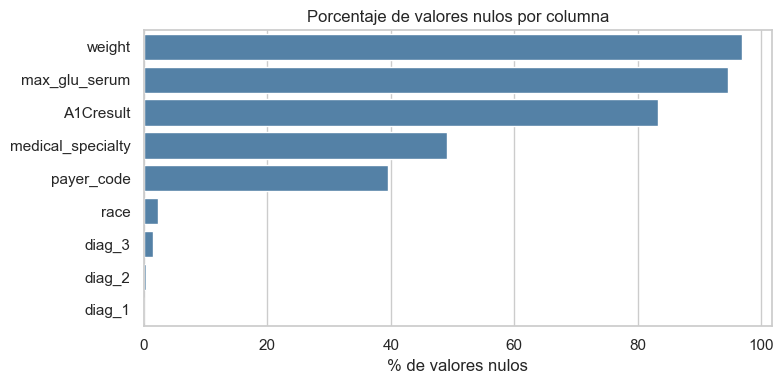

In [8]:
nulos = resumen[resumen["n_nulos"] > 0].sort_values("%_nulos", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=nulos["%_nulos"], y=nulos.index, ax=ax, color="steelblue")
ax.set_xlabel("% de valores nulos")
ax.set_ylabel("")
ax.set_title("Porcentaje de valores nulos por columna")
plt.tight_layout()
plt.show()

> **Codigo: .** Filtramos de `resumen` solo las columnas con al menos un nulo y graficamos su porcentaje en un gráfico de barras horizontales ordenado.
>
> **Por qué.** La tabla anterior tiene 48 filas y hay que leerla con atención; el gráfico responde de un vistazo a la pregunta "qué tan grave es el problema de faltantes y en cuántas columnas". Filtramos las columnas completas porque 39 barras en cero solo serían ruido visual.
>
> **Qué descubrimos.** Los faltantes **no son un problema homogéneo**: se ven tres bloques muy distintos, y cada uno pide una decisión diferente.
>
> 1. **Casi vacías (más del 80%):** `weight` (96.9%), `max_glu_serum` (94.7%) y `A1Cresult` (83.3%).
> 2. **Parcialmente vacías (40-50%):** `medical_specialty` (49.1%) y `payer_code` (39.6%).
> 3. **Prácticamente completas (menos del 2.5%):** `race`, `diag_3`, `diag_2` y `diag_1` (esta última con una barra invisible: 21 filas).
>
> Y la decisión para cada bloque:
> - `weight` se **descarta**: con 3,197 valores de 101,766 no hay forma de imputarla sin inventar datos.
> - `max_glu_serum` y `A1Cresult` **no se imputan ni se descartan**. Como acabamos de ver, su `NaN` significa "la prueba no se realizó", y eso **es un dato en sí mismo**. De hecho, el paper original de este dataset (*"Impact of HbA1c Measurement on Hospital Readmission Rates"*) estudia exactamente eso: si medir la HbA1c cambia la tasa de reingreso. Convertirlas a una categoría explícita `"No medido"` conserva esa señal; imputarlas la destruiría.
> - `medical_specialty` y `payer_code`: mismo tratamiento, categoría `"Desconocido"`. Que no se haya registrado la especialidad o la aseguradora puede correlacionar con el tipo de ingreso.
> - `race`, `diag_1`, `diag_2` y `diag_3`: son tan pocos casos que se pueden imputar con la moda o eliminar esas filas sin impacto apreciable.
>
> **Lección general del EDA:** antes de imputar un `NaN` hay que preguntarse *por qué* falta. Si falta porque nadie lo midió, la ausencia es información y hay que codificarla, no rellenarla.

## 4. Variable objetivo: `readmitted`

Variable categorica con 3 clases: el paciente no fue readmitido (`NO`), fue readmitido despues de 30 dias
(`>30`) o fue readmitido antes de 30 dias (`<30`). Esta ultima suele ser la clase de mayor interes clinico
y esta desbalanceada frente a las otras dos.

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
readmitted
NO     53.9
>30    34.9
<30    11.2
Name: count, dtype: float64


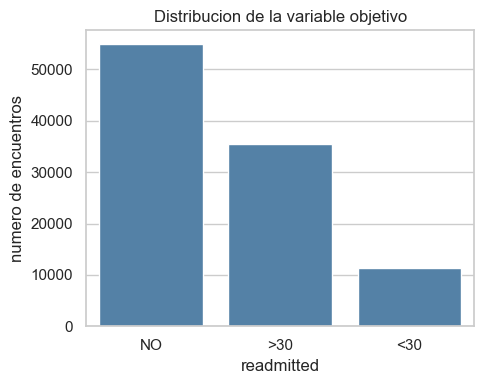

In [9]:
conteo = df["readmitted"].value_counts()
print(conteo)
print((conteo / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=conteo.index, y=conteo.values, ax=ax, color="steelblue", order=["NO", ">30", "<30"])
ax.set_xlabel("readmitted")
ax.set_ylabel("numero de encuentros")
ax.set_title("Distribucion de la variable objetivo")
plt.tight_layout()
plt.show()

> **Codigo: .** Contamos los encuentros de cada una de las 3 clases de `readmitted`, calculamos sus porcentajes y las graficamos en el orden lógico `NO`, `>30`, `<30`.
>
> **Por qué.** El target es la variable más importante del análisis: su distribución determina la métrica de evaluación y la estrategia de modelado. Y hay que mirarla **antes** de explorar los predictores, porque condiciona cómo se interpreta todo lo demás.
>
> **Qué descubrimos.**
> - **`NO`: 54,864 encuentros (53.9%)**, **`>30`: 35,545 (34.9%)** y **`<30`: 11,357 (11.2%)**.
> - Casi la mitad de los encuentros (**46.1%**) termina en un reingreso en algún momento. Es una cifra alta, coherente con que hablamos de pacientes crónicos.
> - **La clase que importa es la minoritaria.** La readmisión temprana (`<30`) es la de mayor relevancia clínica y económica (en EE.UU. Medicare penaliza a los hospitales por reingresos antes de 30 días), y es **solo 1 de cada 9 encuentros**: un desbalance de aproximadamente **8 a 1**.
> - **Consecuencia práctica muy concreta:** un modelo que prediga "no hay readmisión temprana" para absolutamente todos los pacientes acertaría el **88.8%** de las veces. Eso significa que **el *accuracy* es una métrica inútil en este problema**: hay que evaluar con *recall*, *precision*, F1 o PR-AUC sobre la clase `<30`, y considerar técnicas de balanceo (`class_weight`, submuestreo o SMOTE) al entrenar.
> - Por eso en la sección 8 agrupamos el target en binario (`<30` frente al resto): es la pregunta que realmente queremos responder.

## 5. Variables numericas

In [10]:
num_cols = df.select_dtypes(include="number").columns.tolist()

# Los identificadores no se consideran variables numéricas de análisis
num_cols = [
    col for col in num_cols 
    if col not in ["encounter_id", "patient_nbr"]
]

print(num_cols)
df[num_cols].describe().T

['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


,count,mean,std,min,25%,50%,75%,max
admission_type_id,101766.0,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0


> **Codigo: .** Seleccionamos automáticamente las columnas numéricas con `select_dtypes(include="number")` y calculamos su estadística descriptiva, transpuesta (`.T`) para leerla cómodamente.
>
> **Por qué.** `describe()` resume en una tabla las escalas, los rangos y la forma de cada distribución. Comparar **media contra mediana** revela asimetría, y comparar **percentil 75 contra máximo** revela colas largas y posibles valores extremos.
>
> **Qué descubrimos.**
> - `select_dtypes` devolvió **11 columnas, pero 3 son falsos positivos**: `admission_type_id`, `discharge_disposition_id` y `admission_source_id` son los códigos categóricos que ya habíamos identificado. Sus medias (2.02, 3.72, 5.75) **no tienen ninguna interpretación**. Es un buen recordatorio de que la selección automática por tipo de dato siempre necesita revisión manual.
> - **`time_in_hospital`:** media 4.4 días, mediana 4, mínimo 1 y máximo 14. Distribución razonablemente centrada y acotada por diseño del estudio.
> - **`num_lab_procedures`:** la variable de mayor rango, de 1 a 132, con media 43 y mediana 44. Media y mediana casi iguales, así que es bastante simétrica.
> - **`num_medications`:** media 16, mediana 15, máximo 81. Ligeramente sesgada a la derecha.
> - **`number_outpatient`, `number_emergency` y `number_inpatient`:** aquí está el hallazgo más fuerte. **Su mediana y también su percentil 75 son 0**, pero sus máximos son **42, 76 y 21**. Es decir: la gran mayoría de pacientes no tuvo visitas previas, y unos pocos tuvieron muchísimas. Son distribuciones **extremadamente asimétricas** que necesitarán transformación (`log1p`) o binarización (`tuvo_visitas_previas`, sí/no) antes de modelar.
> - **`number_diagnoses`:** media 7.4, mediana 8, percentil 75 en 9 y máximo 16. Muy concentrada en valores altos: estos pacientes tienen muchas comorbilidades. Ese percentil 75 exactamente en 9, con un máximo de 16, es una señal sospechosa que la celda siguiente nos permitirá confirmar.
> - **Las escalas son muy dispares** (de 0-6 en `num_procedures` a 1-132 en `num_lab_procedures`). Si luego usamos un modelo sensible a distancias (KNN, SVM) o con regularización, hay que **estandarizar**.

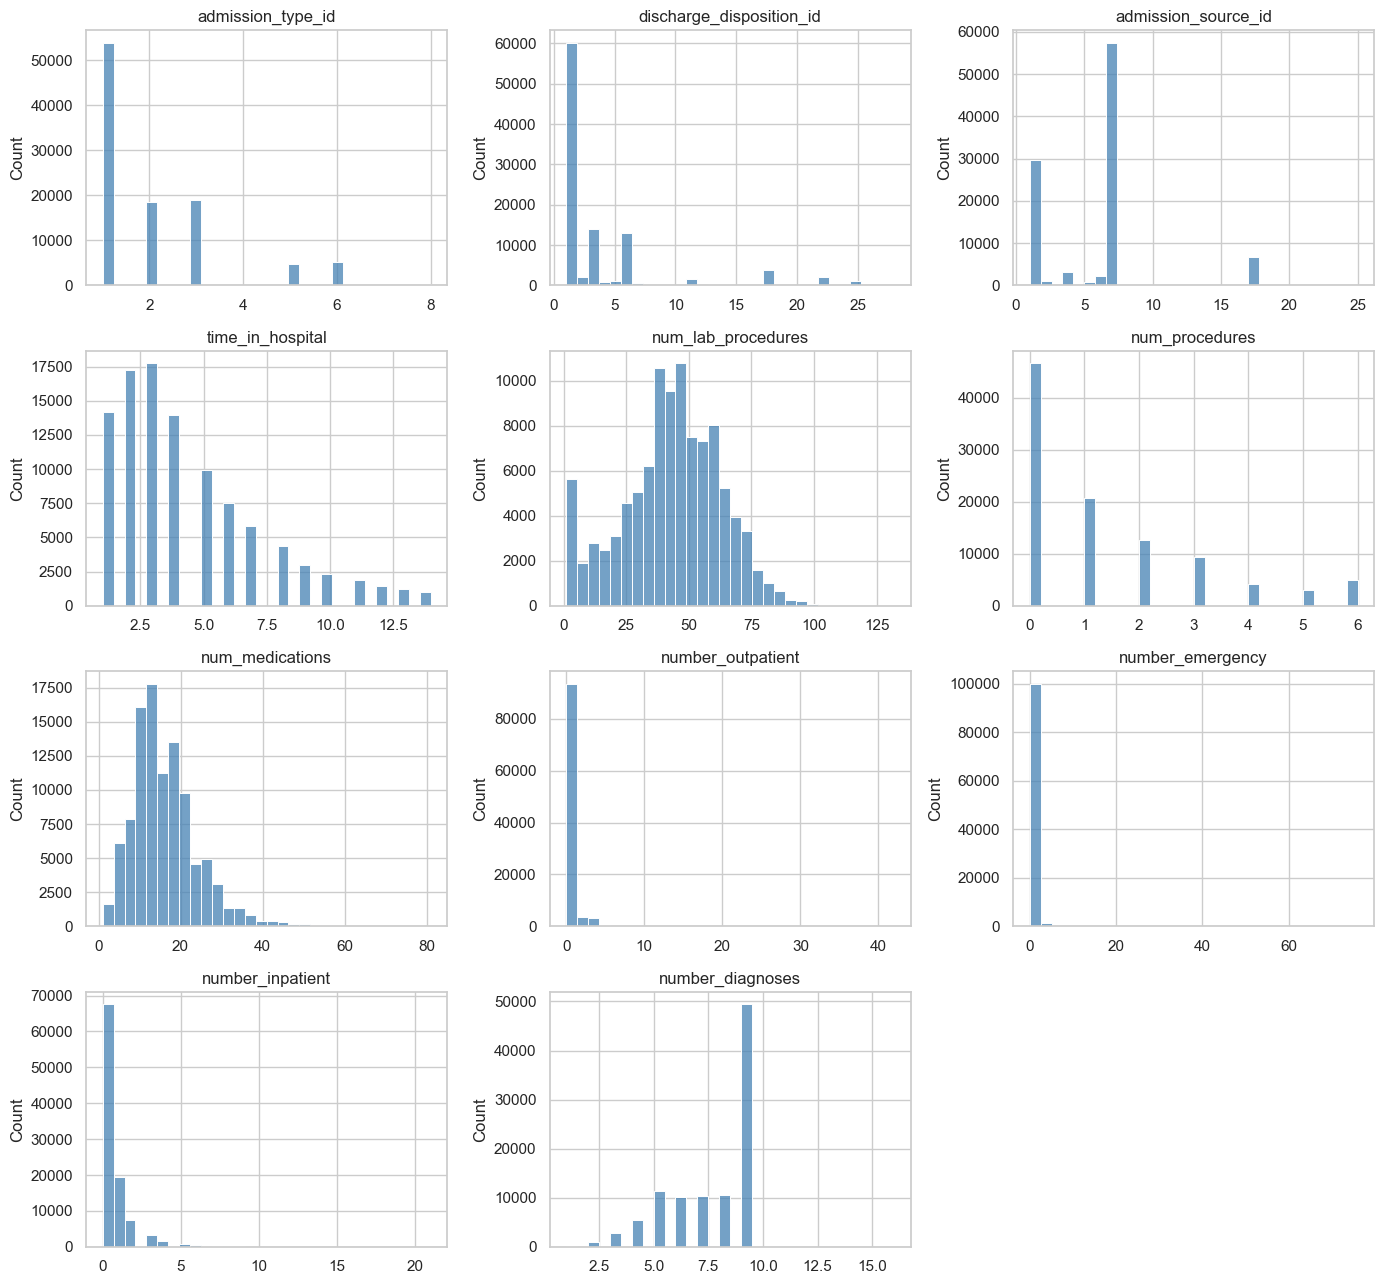

In [11]:
fig, axes = plt.subplots(4, 3, figsize=(14, 13))
for col, ax in zip(num_cols, axes.ravel()):
    sns.histplot(df[col], bins=30, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes.ravel()[len(num_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

> **Codigo: .** Graficamos un histograma de cada una de las 11 variables numéricas en una grilla de 4x3, para ver su forma.
>
> **Por qué.** `describe()` da números; el histograma da la **forma** de la distribución, que los números esconden. Dos variables pueden tener la misma media y la misma mediana y distribuciones completamente distintas (una campana, dos picos, o todo acumulado en un solo valor).
>
> **Qué descubrimos.**
> - **Los tres `*_id` no son números.** Sus histogramas son barras aisladas y separadas, no distribuciones continuas: la confirmación visual de que son códigos categóricos. `discharge_disposition_id` está dominado por el código 1 (unos 60,000 casos, alta a domicilio) y `admission_source_id` se concentra en el 7 (unos 57,000, ingreso por urgencias) y el 1 (unos 29,000, referencia médica). Traducir esos códigos a etiquetas legibles sería un buen paso siguiente.
> - **`time_in_hospital`:** claramente **sesgada a la derecha**, con la moda en 2-3 días y una cola que decae hasta los 14. La mayoría de las estancias son cortas.
> - **`num_lab_procedures`:** aproximadamente una campana centrada en 44, pero **con una anomalía**: un pico aislado en el extremo izquierdo (**5,641 encuentros** con 5 pruebas o menos, y la moda de la variable es **1**, con 3,208 encuentros). Es llamativo, porque el criterio de inclusión del dataset exigía que se hubieran realizado pruebas de laboratorio. **Vale la pena investigar ese grupo**: podría ser un error de registro o un tipo de ingreso particular.
> - **`num_medications`:** campana sesgada a la derecha, moda entre 13 y 15 medicamentos, con cola larga hasta 81.
> - **`num_procedures`:** casi la mitad de los encuentros (unos 47,000) tiene **0 procedimientos**.
> - **`number_outpatient` y `number_emergency`:** una sola barra gigantesca en 0 y el resto invisible. Es la **confirmación visual de la asimetría extrema** que ya sospechábamos por el `describe()`. Un histograma normal no sirve para verlas; habría que usar escala logarítmica en el eje Y.
> - **`number_inpatient`:** decae de forma escalonada y muy marcada: **unos 67,000 encuentros en 0** (el 66% del total), unos 19,000 en 1, unos 7,500 en 2, y a partir de 5 hospitalizaciones previas queda apenas un 2% de los casos. Es asimétrica como las otras dos del historial, pero **con bastante más estructura visible**: aquí sí se distinguen escalones, y eso es justamente lo que la hará útil en la sección 8.
> - **`number_diagnoses`: el hallazgo más llamativo de esta celda.** No es una distribución natural en absoluto: hay una **meseta plana entre 5 y 8** diagnósticos (unos 10,000 encuentros en cada valor) y de golpe un **pico enorme en exactamente 9, con 49,474 encuentros, casi la mitad del dataset (48.6%)**. Y por encima de 9 la variable **se corta en seco**: solo **115 registros de 101,766** (el 0.11%) tienen más de 9 diagnósticos, aunque el máximo llegue a 16.
>   - Eso no es un patrón clínico, es un **artefacto administrativo**: el sistema de facturación permitía registrar hasta 9 códigos de diagnóstico, así que "9" en realidad significa "9 o más". La variable está **truncada (censurada) por arriba**.
>   - **Consecuencia práctica:** tratarla como un conteo continuo es engañoso, porque la diferencia entre 8 y 9 no es comparable a la que hay entre 5 y 6. Es más honesto convertirla en categórica o agrupada (por ejemplo `1-5`, `6-8`, `9+`), y desconfiar de los 115 valores por encima de 9, que probablemente vengan de un sistema de registro distinto.
>   - Es un buen ejemplo de por qué el EDA visual importa: en el `describe()` esta variable parecía perfectamente normal (media 7.4, mediana 8), y solo el histograma revela que **casi la mitad de los datos está apilada en un único valor por un límite del software, no de la medicina**.

## 6. Variables categoricas clave

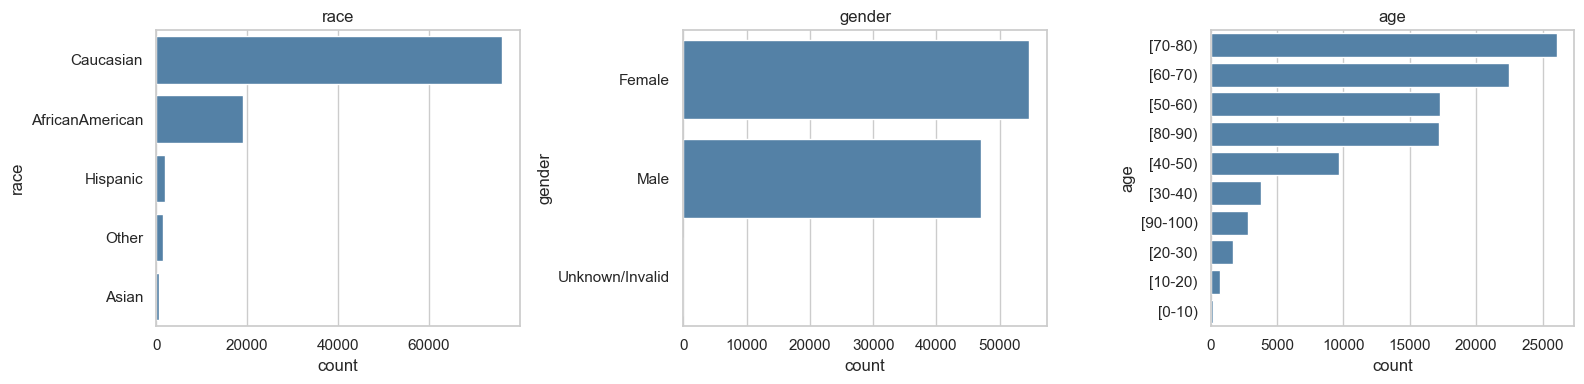

In [12]:
cat_demo = ["race", "gender", "age"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for col, ax in zip(cat_demo, axes):
    orden = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=orden, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

> **Codigo: .** Graficamos la frecuencia de las tres variables demográficas (`race`, `gender`, `age`) con barras horizontales, ordenadas de mayor a menor.
>
> **Por qué.** Necesitamos saber **a quién representan estos datos** antes de generalizar cualquier conclusión. Además, este dataset está marcado como `sensitive_data`, así que identificar los grupos poco representados es una cuestión de rigor: sobre un grupo con pocos casos no se pueden sacar conclusiones fiables, y un modelo entrenado así tenderá a funcionar peor precisamente en esos grupos.
>
> **Qué descubrimos.**
> - **`race`:** fuertemente dominada por `Caucasian` (unos 75,000) y `AfricanAmerican` (unos 19,000). `Hispanic`, `Other` y `Asian` juntas no llegan al 5% del total. Cualquier análisis desagregado por raza será sólido para los dos primeros grupos y poco fiable para los demás. Recordemos además su 2.2% de nulos.
> - **`gender`:** reparto bastante equilibrado, `Female` (unos 54,000) algo por encima de `Male` (unos 47,000). Pero aparece una tercera categoría, **`Unknown/Invalid`, con una barra prácticamente inexistente**: son los 3 valores únicos que ya habíamos visto en `resumen`. Es un puñado de registros inválidos que conviene eliminar o convertir a nulos.
> - **`age`:** el hallazgo más relevante de esta celda. La población es **mayoritariamente de edad avanzada**: el pico está en **`[70-80)` (unos 26,000)**, seguido de `[60-70)` (unos 22,000), y luego `[50-60)` y `[80-90)` (unos 17,000 cada uno). Los tramos por debajo de 30 años son casi inexistentes. Esto es coherente con la diabetes tipo 2, pero significa que **las conclusiones de este análisis aplican a población adulta mayor**, no a pacientes jóvenes.
> - Como ya notamos, `age` es **ordinal** (los rangos tienen un orden natural). Para modelar conviene mapearla a un valor numérico (el punto medio: 5, 15, 25...) o codificarla como ordinal, **nunca** con one-hot, que tiraría a la basura esa información de orden.

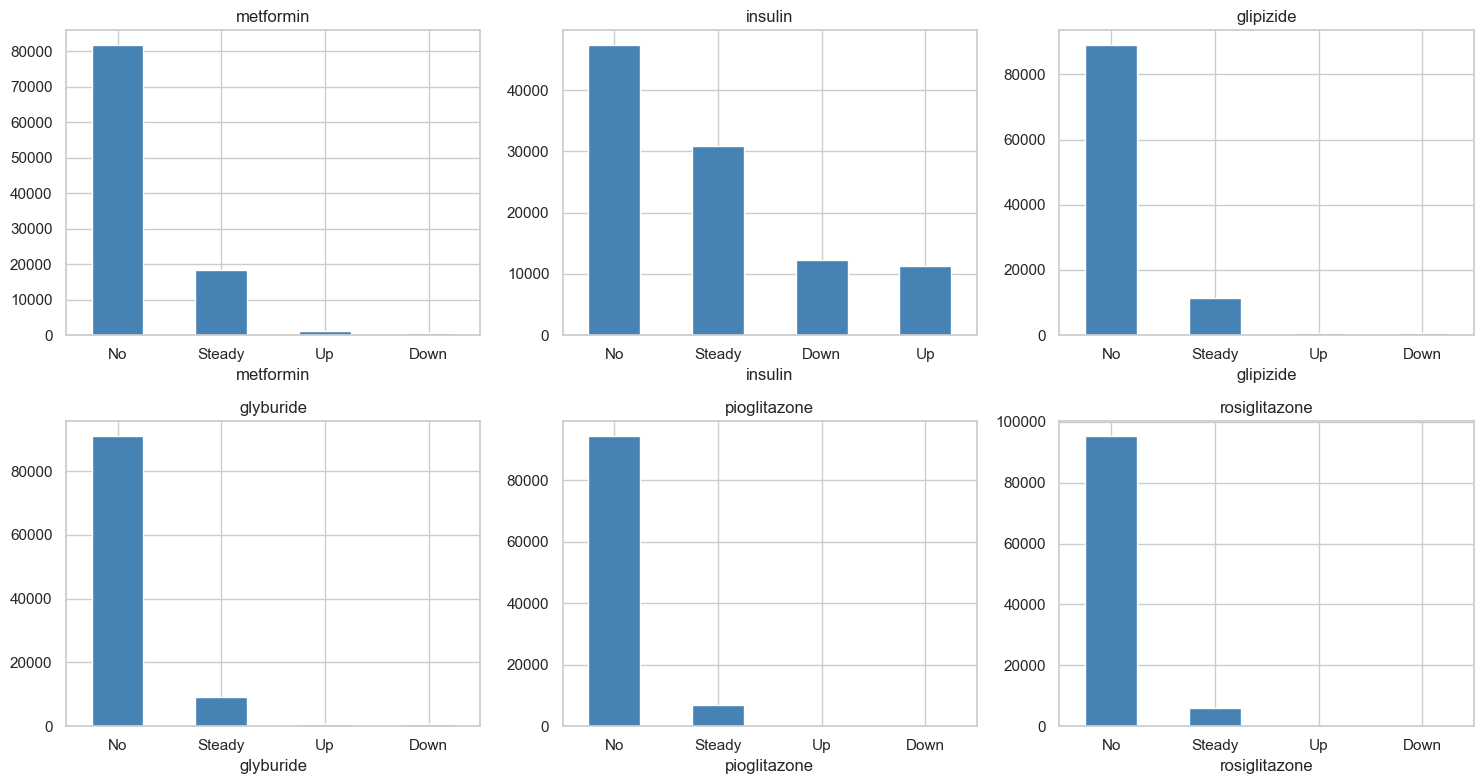

In [13]:
# variables de medicacion: para cada droga, que tan frecuente es cada categoria (No / Steady / Up / Down)
drogas = [
    "metformin", "insulin", "glipizide", "glyburide", "pioglitazone", "rosiglitazone",
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(drogas, axes.ravel()):
    df[col].value_counts().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

> **Codigo: .** Para 6 de las 23 columnas de medicamentos, graficamos cuán frecuente es cada una de sus 4 categorías: `No` (no se recetó), `Steady` (dosis sin cambios), `Up` (se aumentó) y `Down` (se redujo).
>
> **Por qué.** Ya sospechábamos por la cardinalidad de `resumen` que muchas de estas columnas aportan poco. Aquí lo verificamos: una variable en la que el 95% de los casos cae en la misma categoría tiene muy poca **varianza**, y sin varianza no hay capacidad predictiva. El objetivo es decidir cuáles conservar.
>
> **Qué descubrimos.**
> - **`insulin` es la excepción, y la variable de medicación más informativa del dataset.** Es la única con un reparto real entre las cuatro categorías: `No` unos 47,000, `Steady` unos 31,000, `Down` unos 12,000 y `Up` unos 11,000. Es decir, **más de la mitad de los encuentros la usan** y en cerca del 23% **se ajustó la dosis** durante la estancia. Ese ajuste es una señal clínica valiosa: apunta a descontrol glucémico.
> - **`metformin`** tiene algo de variabilidad (unos 81,000 `No` frente a unos 18,000 `Steady`), pero casi ningún ajuste de dosis.
> - **`glipizide`, `glyburide`, `pioglitazone` y `rosiglitazone`** están entre el 88% y el 95% en `No`, con `Up` y `Down` prácticamente en cero. Son **casi constantes**.
> - **Conclusión práctica:** aplicar one-hot encoding a las 23 columnas de medicamentos generaría decenas de columnas casi vacías que solo agregan ruido y dimensionalidad. Es mucho mejor **quedarse con `insulin` (y quizá `metformin`) y construir variables agregadas**, por ejemplo `n_farmacos_activos` (cuántos medicamentos distintos recibe el paciente) o `hubo_ajuste_de_dosis` (si algún fármaco aparece como `Up` o `Down`). Esto se llama *feature engineering*: crear variables con más señal a partir de las originales.
>
> **Nota cosmética:** en cada subgráfico el nombre del fármaco aparece dos veces (como título y como etiqueta del eje X), porque el `plot(kind="bar")` de pandas escribe el nombre del índice automáticamente. Se limpia agregando `ax.set_xlabel("")` dentro del bucle.

In [14]:
print("change:")
print(df["change"].value_counts(normalize=True).round(3), "\n")
print("diabetesMed:")
print(df["diabetesMed"].value_counts(normalize=True).round(3))

change:
change
No    0.538
Ch    0.462
Name: proportion, dtype: float64 

diabetesMed:
diabetesMed
Yes    0.77
No     0.23
Name: proportion, dtype: float64


> **Codigo: .** Calculamos las proporciones (`normalize=True`) de las dos variables que resumen la medicación: `change` (si hubo algún cambio en la medicación diabética) y `diabetesMed` (si se administró alguna medicación diabética).
>
> **Por qué.** Son las dos únicas variables de medicación que **vienen ya agregadas** en el dataset, precisamente el tipo de resumen que acabamos de proponer construir. Usamos proporciones en lugar de conteos porque con 101,766 filas los porcentajes se interpretan mucho más rápido.
>
> **Qué descubrimos.**
> - **`change`: 53.8% `No` frente a 46.2% `Ch`.** Un balance casi perfecto, el mejor que hemos visto en todo el análisis. En **casi la mitad de los encuentros se modificó la medicación diabética**, lo que habla de una gestión muy activa (o de pacientes muy inestables).
> - **`diabetesMed`: 77% `Yes` frente a 23% `No`.** Algo desbalanceada pero perfectamente utilizable. Llama la atención que **casi 1 de cada 4 encuentros de un paciente diabético no incluya medicación diabética** durante la estancia.
> - **Ambas son candidatas muy fuertes para modelar:** están balanceadas, no tienen ningún nulo y resumen en un solo valor lo que las 23 columnas de fármacos expresan de forma dispersa. Es el contraste exacto con la celda anterior: **una variable agregada y balanceada vale más que veinte variables casi constantes**.
> - **Chequeo de consistencia pendiente:** por definición, si `diabetesMed = No` no puede haber habido cambio de medicación, así que esos casos deberían tener todos `change = No`. Conviene verificarlo con una tabla cruzada (`pd.crosstab`); si aparecen contradicciones, hay un problema de calidad en los datos.

## 7. Correlacion entre variables numericas

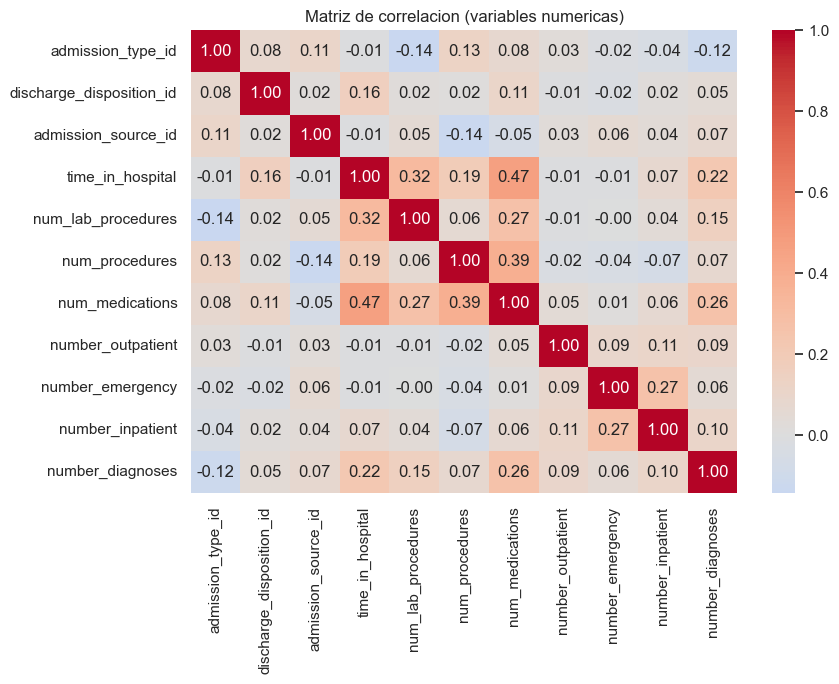

In [15]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlacion (variables numericas)")
plt.tight_layout()
plt.show()

> **Codigo: .** Calculamos la matriz de correlación de Pearson entre las 11 variables numéricas y la visualizamos como mapa de calor, con los valores anotados y una paleta divergente centrada en 0 (rojo = correlación positiva, azul = negativa).
>
> **Por qué.** Buscamos dos cosas: **redundancia** (variables que miden prácticamente lo mismo, lo que se llama multicolinealidad y perjudica a los modelos lineales) y **estructura** (grupos de variables que se mueven juntas y que quizá puedan resumirse en una sola). El mapa de calor permite leer 121 números de un vistazo.
>
> **Qué descubrimos.**
> - **No hay redundancia grave.** La correlación más alta entre dos variables distintas es **0.47**, muy lejos del 0.8-0.9 que obligaría a eliminar una de ellas. Podemos conservar todas las variables numéricas.
> - **Se distinguen dos bloques independientes entre sí:**
>   1. **Intensidad del episodio actual:** `num_medications` con `time_in_hospital` **0.47**, `num_medications` con `num_procedures` **0.39**, `time_in_hospital` con `num_lab_procedures` **0.32**, `num_medications` con `num_lab_procedures` **0.27**, `num_medications` con `number_diagnoses` **0.26** y `time_in_hospital` con `number_diagnoses` **0.22**. Todas positivas y moderadas, y tienen todo el sentido clínico: **estancias más largas implican más pruebas, más fármacos y más diagnósticos**. Este bloque podría resumirse en un único índice de gravedad o intensidad del ingreso.
>   2. **Historial previo del paciente:** `number_emergency` con `number_inpatient` **0.27** y `number_outpatient` con `number_inpatient` **0.11**. Es un grupo aparte, con correlaciones cercanas a 0 frente a todo el bloque anterior. Este es un hallazgo útil: **el historial previo aporta información completamente distinta de la del episodio actual**, así que ambos grupos merecen estar en el modelo.
> - Los valores de los tres `*_id` (por ejemplo `discharge_disposition_id` con `time_in_hospital`, 0.16) **no deben interpretarse**: son categorías codificadas y la correlación de Pearson sobre ellas no significa nada.
> - **Limitación metodológica importante:** Pearson mide solo relaciones **lineales** y asume variables continuas. Con conteos tan asimétricos como `number_outpatient` o `number_emergency` (casi todo ceros), **subestima la asociación real**. Para esas variables la **correlación de Spearman** (basada en rangos) sería más apropiada. Una correlación cercana a 0 no significa ausencia de relación, solo ausencia de relación *lineal*.
> - Recordemos además lo que acabamos de descubrir sobre `number_diagnoses`: como está truncada en 9, sus correlaciones (0.26 con `num_medications`, 0.22 con `time_in_hospital`) están **atenuadas** respecto a las reales.

## 8. Relacion de variables con el target

Se agrupa `readmitted` en dos clases (readmitido antes de 30 dias vs. el resto) para explorar mas facil
su relacion con otras variables. Esta seccion pone a prueba la hipotesis del equipo: que los pacientes
con mas hospitalizaciones previas (number_inpatient) tienen una tasa de readmision temprana mayor que
los que no las tienen. De paso miramos tambien number_emergency e insulin.


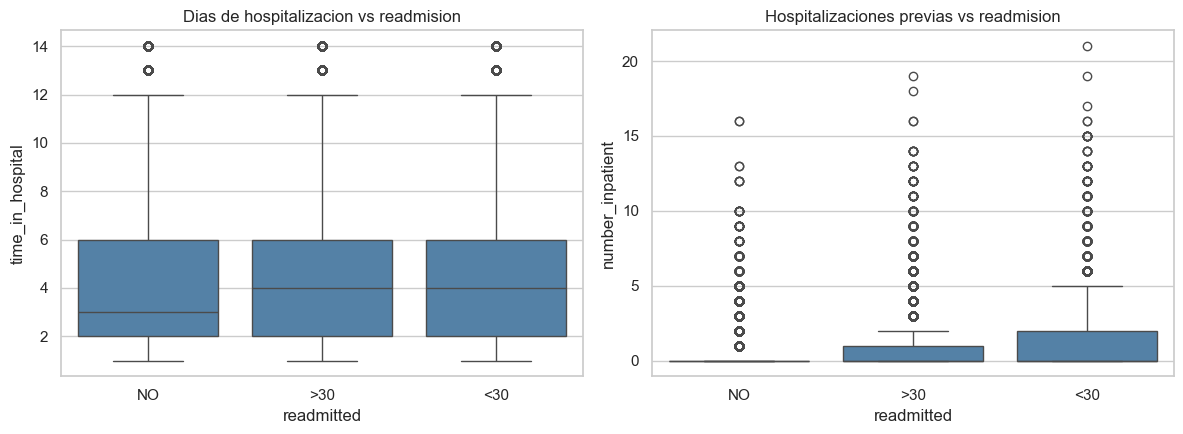

In [16]:
df["readmit_30"] = (df["readmitted"] == "<30")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x="readmitted", y="time_in_hospital", order=["NO", ">30", "<30"], ax=axes[0], color="steelblue")
axes[0].set_title("Dias de hospitalizacion vs readmision")

sns.boxplot(data=df, x="readmitted", y="number_inpatient", order=["NO", ">30", "<30"], ax=axes[1], color="steelblue")
axes[1].set_title("Hospitalizaciones previas vs readmision")

plt.tight_layout()
plt.show()

> **Codigo: .** Creamos la variable binaria `readmit_30` (`True` si el reingreso fue en menos de 30 días) y comparamos con diagramas de caja cómo se distribuyen `time_in_hospital` y `number_inpatient` en cada clase del target.
>
> **Por qué.** Hasta ahora habíamos mirado cada variable por separado; este es el paso clave del EDA: **relacionar los predictores con el target**. Si la distribución de una variable cambia entre los grupos, esa variable tiene poder predictivo; si es igual en todos, no aporta. El diagrama de caja es ideal para esta comparación porque muestra a la vez mediana, dispersión y valores extremos. Y binarizar el target simplifica el problema a la pregunta que de verdad interesa: **¿volverá este paciente en menos de 30 días?**
>
> **Qué descubrimos.**
> - **`time_in_hospital` discrimina muy poco.** Las tres cajas son casi idénticas (rango intercuartílico de 2 a 6 días en todas) y las medianas apenas se mueven: **3 días en `NO` frente a 4 en `>30` y en `<30`**. Hay una tendencia en la dirección esperada, pero tan débil que **por sí sola esta variable es un predictor pobre**. Un hallazgo negativo también es un hallazgo: nos evita apostar por ella.
> - **`number_inpatient` sí discrimina, y con claridad.** Es el mejor predictor que hemos encontrado hasta ahora:
>   - En `NO` la caja entera está **colapsada en 0**: la gran mayoría de quienes no reingresan **no había estado hospitalizada el año anterior**.
>   - En `>30` la caja va de **0 a 1**.
>   - En `<30` la caja va de **0 a 2** y el bigote llega hasta 5.
>   - El patrón es inequívoco y además **monótono**: cuantas más hospitalizaciones previas, más probable y más temprano es el reingreso. Tiene mucho sentido clínico, porque refleja pacientes crónicos descompensados.
> - **Los puntos extremos no son errores.** En `number_inpatient` aparecen muchísimos puntos por encima del bigote (hasta **21 hospitalizaciones previas**), pero eso es consecuencia directa de la asimetría que ya vimos: cuando la mediana y el percentil 75 valen 0, la regla del diagrama de caja marca como extremo casi cualquier valor positivo. Son **pacientes crónicos reales, no ruido**, y precisamente los más relevantes para predecir reingresos: **eliminarlos sería un error grave**.

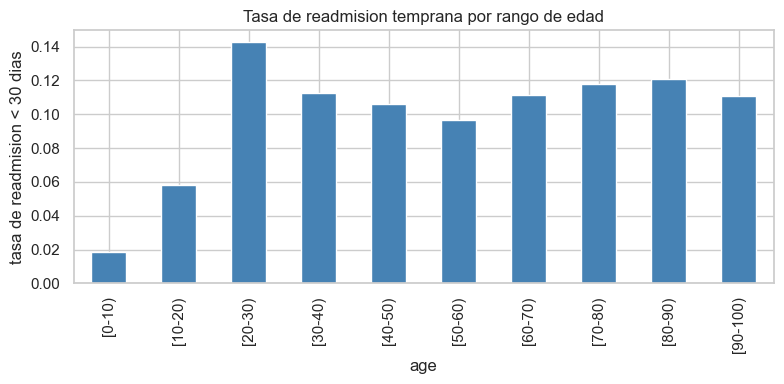

In [17]:
tasa_por_edad = df.groupby("age")["readmit_30"].mean().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
tasa_por_edad.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("tasa de readmision < 30 dias")
ax.set_title("Tasa de readmision temprana por rango de edad")
plt.tight_layout()
plt.show()

> **Codigo: .** Agrupamos por tramo de edad y calculamos la **media** de `readmit_30`. Como es una variable booleana, su media es directamente la **proporción de reingresos tempranos** de ese grupo. Ordenamos por índice para respetar el orden natural de la edad, no la frecuencia.
>
> **Por qué.** Es un cambio de pregunta importante respecto a la sección 6. Allí contamos **cuántos pacientes** hay en cada tramo de edad; aquí medimos **qué proporción de ellos reingresa**. Son cosas distintas: un grupo puede ser muy numeroso y reingresar poco, o muy pequeño y reingresar mucho. Para evaluar riesgo, lo que importa es la tasa. El truco de aplicar `mean()` a una columna booleana es un patrón muy útil en pandas.
>
> **Qué descubrimos.**
> - Como referencia, la tasa global es **11.2%**.
> - **Los tramos con volumen de datos son notablemente planos:** desde `[30-40)` hasta `[90-100)` todas las tasas caen entre **9.6% y 12.1%**. Se aprecia una leve tendencia creciente, con el mínimo en `[50-60)` (**9.6%**) y el máximo en `[80-90)` (**12.1%**), pero la diferencia es de apenas 2.5 puntos.
> - **Los extremos jóvenes son los que más se salen del patrón:** `[0-10)` tiene solo **1.8%**, `[10-20)` **5.7%**, y `[20-30)` es **la tasa más alta de todo el gráfico, 14.2%**.
> - **Pero hay que ser prudentes con esos extremos.** Son justamente los tramos con menos encuentros: en el gráfico de `age` de la sección 6 sus barras eran casi invisibles. Con pocos casos, un puñado de pacientes mueve mucho el porcentaje, así que **esas tasas son inestables y no conviene sobreinterpretarlas**. Lo correcto sería acompañar cada barra con su número de casos o con un intervalo de confianza. Es una lección importante del EDA: **una tasa sin su tamaño de muestra puede engañar**.
> - **Conclusión:** la edad aporta señal, pero **débil y no monótona**. No sirve como predictor principal, aunque sí puede ayudar combinada con otras variables. El contraste con `number_inpatient` de la celda anterior ilustra muy bien la diferencia entre una variable con señal fuerte y una con señal marginal.

number_emergency es, junto con number_inpatient, parte del bloque de "historial previo" que salio independiente en la correlacion (seccion 7). Vale la pena ver si tambien se mueve con la readmision.


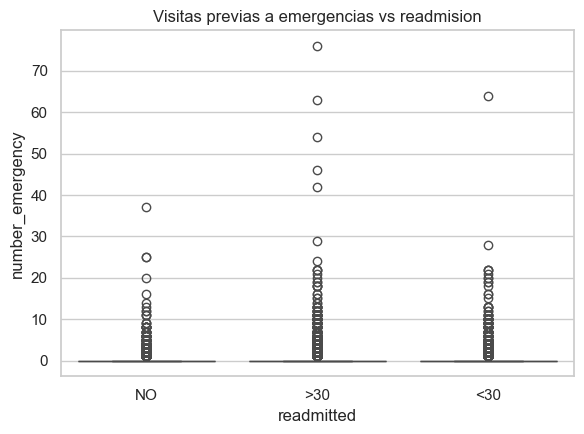

In [18]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df, x="readmitted", y="number_emergency", order=["NO", ">30", "<30"], ax=ax, color="steelblue")
ax.set_title("Visitas previas a emergencias vs readmision")
plt.tight_layout()
plt.show()


insulin es la unica columna de medicamentos que no esta casi toda concentrada en "No" (seccion 6). Aca comparamos la tasa de readmision temprana entre pacientes con ajuste de dosis (Up/Down), dosis estable (Steady) y sin insulina (No).


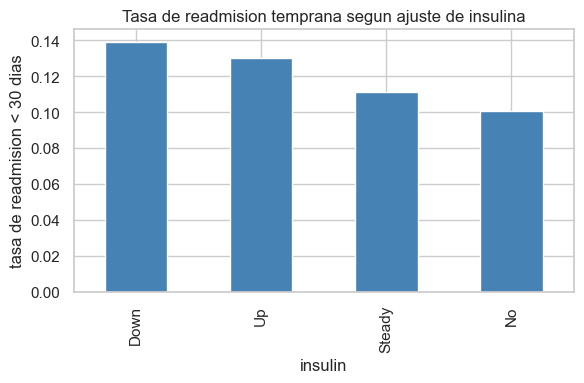

In [19]:
tasa_por_insulin = df.groupby("insulin")["readmit_30"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
tasa_por_insulin.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("tasa de readmision < 30 dias")
ax.set_title("Tasa de readmision temprana segun ajuste de insulina")
plt.tight_layout()
plt.show()


## 9. Conclusiones preliminares

### Estructura y calidad de los datos

- El dataset tiene **101,766 encuentros y 47 variables**, sin filas duplicadas. Pero la **unidad de analisis es el encuentro hospitalario, no el paciente**: los 101,766 encuentros pertenecen a solo **71,518 pacientes**, y el **46.2% de las filas** corresponde a pacientes que aparecen mas de una vez. **Casi la mitad de las filas no son observaciones independientes**, aunque ninguna este duplicada.
- **Decision tomada: conservamos todos los encuentros.** El encuentro es la unidad correcta para la pregunta real (Medicare penaliza por ingreso, y un modelo puntuaria cada admision), y reducir a un encuentro por paciente descartaria el 30% de los datos y toda la informacion de trayectoria. A cambio, el analisis asume tres cuidados obligatorios: **el split debe agrupar por `patient_nbr`** (`StratifiedGroupKFold`, nunca un `train_test_split` aleatorio, que dejaria el **41.5%** de las filas de test con un paciente ya visto en train), **los identificadores nunca son features**, y **toda cifra descriptiva debe declarar si es por encuentro o por paciente**.
- **La duplicacion desplaza las estadisticas y hay que tenerlo presente al leer todo lo que sigue:** quedandose con el primer encuentro de cada paciente, la tasa de readmision temprana baja del 11.16% al 8.80% y la media de `number_inpatient` cae de 0.64 a 0.18.
- **Los valores faltantes no son todos iguales y no se tratan igual.** `weight` (96.9%) se descarta sin mas. En cambio, el `NaN` de `max_glu_serum` (94.7%) y `A1Cresult` (83.3%) **significa "la prueba no se realizo"**: es informacion, no un dato perdido, y debe pasar a una categoria explicita `"No medido"`. Mismo criterio para `medical_specialty` (49.1%) y `payer_code` (39.6%) con `"Desconocido"`. `race` y los `diag_*` tienen tan pocos nulos que se pueden imputar o eliminar.
- **Hay columnas que no aportan absolutamente nada:** `examide` y `citoglipton` tienen un unico valor (varianza cero) y se deben eliminar; otras siete columnas de medicamentos tienen solo dos valores y son casi constantes.
- **Tres variables `int64` son en realidad categoricas:** `admission_type_id`, `discharge_disposition_id` y `admission_source_id`. Sus medias, sus histogramas y sus correlaciones no tienen interpretacion, y hay que recodificarlas antes de modelar.
y solo **115 registros** superan ese valor. No es un conteo continuo real, asi que conviene agruparla (`1-5`, `6-8`, `9+`).
`medical_specialty`, con 72 categorias, tiene el mismo problema en menor escala.
- **Anomalia pendiente de investigar:** **5,641 encuentros** tienen 5 pruebas de laboratorio o menos, y de hecho la **moda de `num_lab_procedures` es 1** (3,208 encuentros), a pesar de que el criterio de inclusion del dataset exigia que se hubieran realizado pruebas de laboratorio.

### La variable objetivo

- El target esta **desbalanceado**: `NO` 53.9%, `>30` 34.9% y `<30` solo **11.2%**. La clase de mayor interes clinico y economico (readmision antes de 30 dias) es justamente la minoritaria, con un desbalance cercano a **8 a 1**.
- **Consecuencia directa y concreta:** predecir "sin readmision temprana" para todos los pacientes daria un **88.8% de acierto**, asi que **el accuracy no sirve como metrica en este problema**. Hay que evaluar con recall, precision, F1 o PR-AUC sobre la clase `<30`, y aplicar balanceo de clases (`class_weight`, submuestreo o SMOTE).

### Variables con mas y con menos senal

- **`number_inpatient` es el predictor mas prometedor** de todos los explorados: la caja esta colapsada en 0 para los no readmitidos, va de 0 a 1 en `>30` y de 0 a 2 en `<30`, con un patron monotono y clinicamente coherente. Sus valores extremos (hasta 21 ingresos previos) son pacientes cronicos reales y **no se deben eliminar**.
- **`time_in_hospital` discrimina poco** por si solo (mediana de 3 dias en `NO` frente a 4 en las clases readmitidas), y **la edad aporta una senal debil y no monotona**: entre `[30-40)` y `[90-100)` la tasa apenas se mueve (9.6% a 12.1%). Las tasas llamativas de los tramos jovenes (1.8% en `[0-10)`, 14.2% en `[20-30)`) se apoyan en muy pocos casos y son inestables.
- **De las 23 columnas de medicamentos, `insulin` es la unica realmente informativa:** la usa el **53.4%** de los encuentros y en el **23.1%** se ajusto la dosis durante la estancia. El resto esta entre el 88% y el 95% en `No`. En lugar de codificarlas todas, conviene construir variables agregadas (`n_farmacos_activos`, `hubo_ajuste_de_dosis`).
- **`change` (46.2% / 53.8%) y `diabetesMed` (77% / 23%) son las mejores candidatas categoricas:** completas, balanceadas y ya agregadas. Queda pendiente verificar su consistencia con una tabla cruzada (si `diabetesMed = No`, `change` deberia ser siempre `No`).
- **No hay multicolinealidad grave** (correlacion maxima 0.47) y se distinguen **dos bloques independientes entre si**: la intensidad del episodio actual (`time_in_hospital`, `num_medications`, `num_lab_procedures`, `num_procedures`, `number_diagnoses`) y el historial previo del paciente (`number_outpatient`, `number_emergency`, `number_inpatient`). Al ser independientes, **cada bloque aporta informacion distinta** y ambos merecen estar en el modelo.
- Los tres conteos de visitas previas son **extremadamente asimetricos** (mediana y percentil 75 en 0), asi que necesitan `log1p` o binarizacion. Para ellos **Spearman seria mas apropiado que Pearson**, que subestima su asociacion real.

### Limitaciones y alcance

- La poblacion es **mayoritariamente adulta mayor**: el **81.6%** de los encuentros esta entre los 50 y los 90 anos, con el pico en `[70-80)`. Las conclusiones **no se pueden extrapolar a pacientes jovenes**.
- `race` esta dominada por dos grupos (`Caucasian` 74.8% y `AfricanAmerican` 18.9%); `Hispanic`, `Other` y `Asian` juntas suman apenas el 4.1%. Cualquier resultado desagregado por raza sera poco fiable en esos grupos, y un modelo entrenado sobre estos datos tendera a funcionar peor precisamente ahi. `gender` incluye 3 registros `Unknown/Invalid` que conviene eliminar.
- Los datos son de **1999-2008 y de 130 hospitales de EE.UU.**, con un criterio de inclusion estricto (estancias de 1 a 14 dias, con pruebas de laboratorio y medicacion administrada). No representan la practica clinica actual ni otros sistemas de salud.


### La hipotesis, hasta donde alcanza el EDA

number_inpatient sigue siendo la variable con la relacion mas clara y monotona con la readmision temprana, y es la variable central de la hipotesis del equipo. De las otras dos predictoras del white paper, insulin tambien dio una senal util y ordenada: la tasa de readmision antes de 30 dias baja de forma escalonada segun el tipo de ajuste de dosis, mas alta con reduccion (Down, cerca de 13.9%), luego aumento (Up, cerca de 13.0%), despues dosis estable (Steady, cerca de 11.1%), y mas baja sin insulina (No, cerca de 10.0%). Un ajuste de dosis, sobre todo una reduccion, coincide con mas riesgo de reingreso temprano.

number_emergency, en cambio, no dejo ver nada claro con un boxplot: la variable esta tan concentrada en 0 (mediana 0 en las tres clases de readmitted) que la caja se aplasta y solo se distinguen los valores atipicos. Haria falta otra vista (por ejemplo, agrupar en tuvo visitas a emergencias si/no, como se hizo con la edad) para saber si de verdad aporta señal, algo que se puede resolver en la Parte II.

En conjunto, esto es solo el EDA, no una prueba: falta el modelado de la Parte II para confirmar cuales de estas variables siguen siendo relevantes una vez controladas por las demas.


# INICIO DE LA PARTE DOS DEL PROYECTO

## 10. Preparación de datos para modelado

In [20]:
#Se crea una copia del conjunto utilizado durante el EDA para realizar la preparación del modelado 
#sin modificar los datos originales. A partir de este punto, todas las transformaciones las realizamos sobre df_modelo.

df_modelo = df_id.copy()
print("Dimensiones iniciales:", df_modelo.shape)

Dimensiones iniciales: (101766, 50)


In [21]:
#Creamos la variable binaria derivada readmit_30

df_modelo["readmit_30"] = (
    df_modelo["readmitted"] == "<30"
).astype(int)
df_modelo["readmit_30"].value_counts()

readmit_30
0    90409
1    11357
Name: count, dtype: int64

In [22]:
# En nuestro EDA ya vimos que weight tiene 96.9% de faltantes y que examide y citoglipton tienen varianza cero. Así que procedemos a eliminarlas.
columnas_eliminar = [
    "weight",
    "examide",
    "citoglipton"
]

df_modelo = df_modelo.drop(columns=columnas_eliminar)
print("Dimensiones después de eliminar columnas:", df_modelo.shape)

Dimensiones después de eliminar columnas: (101766, 48)


In [23]:
# En el EDA se identifico que en max_glu_serum y A1Cresult el NaN tiene significado: la prueba no fue realizada. 
#Asi que hacemos explicita su categorización.

df_modelo["max_glu_serum"] = (df_modelo["max_glu_serum"].fillna("No medido"))
df_modelo["A1Cresult"] = (df_modelo["A1Cresult"].fillna("No medido"))
df_modelo["medical_specialty"] = (df_modelo["medical_specialty"].fillna("Desconocido"))
df_modelo["payer_code"] = (df_modelo["payer_code"].fillna("Desconocido"))

columnas_revisar = [
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code"
]

df_modelo[columnas_revisar].isna().sum()

max_glu_serum        0
A1Cresult            0
medical_specialty    0
payer_code           0
dtype: int64

In [24]:
# Eliminamos los generos invalidos y desconocidos
print(df_modelo["gender"].value_counts(dropna=False))

df_modelo = df_modelo[
    df_modelo["gender"] != "Unknown/Invalid"
].copy()

print("Filas restantes:", len(df_modelo))

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64
Filas restantes: 101763


In [25]:
faltantes = (
    df_modelo.isna()
    .sum()
    .sort_values(ascending=False)
)

faltantes[faltantes > 0]

race      2271
diag_3    1423
diag_2     358
diag_1      21
dtype: int64

In [26]:
columnas_faltantes = [
    "race",
    "diag_1",
    "diag_2",
    "diag_3"
]

df_modelo[columnas_faltantes] = (
    df_modelo[columnas_faltantes]
    .fillna("Desconocido")
)

print(
    "Faltantes restantes:",
    df_modelo.isna().sum().sum()
)

Faltantes restantes: 0


### Resumen de la limpieza

- Se eliminaron weight, examide y citoglipton por lo identificado en el EDA (96.9% de faltantes y varianza cero). 
- En max_glu_serum y A1Cresult el NaN se recodificó como "No medido" porque representa una prueba no realizada.
- medical_specialty y payer_code se imputaron como "Desconocido" por la misma razón.
- Se eliminaron los registros con género inválido/desconocido.
- Tras estos pasos, el dataset queda sin valores faltantes.

## 11. Ingeniería de características 

In [27]:
# Acá colocamos el punto medio de la edad y lo colocamos una nueva columna a la vez que eliminamos la anterior
mapa_edad = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df_modelo["age_num"] = df_modelo["age"].map(mapa_edad)

display(df_modelo[["age", "age_num"]].drop_duplicates().sort_values("age_num"))
df_modelo = df_modelo.drop(columns="age")  

,age,age_num
0,[0-10),5
1,[10-20),15
2,[20-30),25
3,[30-40),35
4,[40-50),45
5,[50-60),55
6,[60-70),65
7,[70-80),75
8,[80-90),85
9,[90-100),95


In [28]:
columnas_medicamentos = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

columnas_medicamentos = [
    col for col in columnas_medicamentos
    if col in df_modelo.columns
]

df_modelo["n_farmacos_activos"] = (
    df_modelo[columnas_medicamentos]
    .ne("No")
    .sum(axis=1)
)

df_modelo["hubo_ajuste_de_dosis"] = (
    df_modelo[columnas_medicamentos]
    .isin(["Up", "Down"])
    .any(axis=1)
    .astype(int)
)

print(df_modelo["hubo_ajuste_de_dosis"].value_counts(normalize=True))

medicamentos_eliminar = [
    col for col in columnas_medicamentos
    if col != "insulin"
]

df_modelo = df_modelo.drop(
    columns=medicamentos_eliminar
)

hubo_ajuste_de_dosis
0    0.727769
1    0.272231
Name: proportion, dtype: float64


In [29]:
X_modelo = df_modelo.drop(
    columns=[
        "readmitted",
        "readmit_30",
        "encounter_id",
        "patient_nbr"
    ]
)

y_modelo = df_modelo["readmit_30"].astype(int)

groups = df_modelo["patient_nbr"]

print("X:", X_modelo.shape)
print("y:", y_modelo.shape)
print("Pacientes:", groups.nunique())
print()
print("Distribución del target:")
print(y_modelo.value_counts(normalize=True))

X: (101763, 26)
y: (101763,)
Pacientes: 71515

Distribución del target:
readmit_30
0    0.888398
1    0.111602
Name: proportion, dtype: float64


> Separamos la variable objetivo readmit_30 de las variables predictoras y excluimos readmitted para evitar fuga de información, ya que de ella se deriva directamente el target.
> También excluimos encounter_id y patient_nbr porque son identificadores y no variables predictoras.
> Sin embargo, conservamos patient_nbr por separado en groups, ya que se utilizará para garantizar que los encuentros de un mismo paciente permanezcan dentro del mismo grupo durante la separación y validación de los datos.

## 12. Diseño de Evaluación

> Un `train_test_split` aleatorio dejaría encuentros del mismo `patient_nbr` repartidos entre entrenamiento y prueba, ya que un mismo paciente puede tener varios encuentros (sección 1). `StratifiedGroupKFold` agrupa por paciente y a la vez mantiene la proporción de `readmit_30` en ambos conjuntos. Se verifica abajo que la interseccion de pacientes entre train y test sea cero.

In [30]:
# Separamos los datos en entrenamiento y en prueba

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    sgkf.split(
        X_modelo,
        y_modelo,
        groups=groups
    )
)

X_train = X_modelo.iloc[train_idx].copy()
X_test = X_modelo.iloc[test_idx].copy()

y_train = y_modelo.iloc[train_idx].copy()
y_test = y_modelo.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

pacientes_compartidos = (set(groups_train) & set(groups_test))

print("Encuentros train:", len(X_train))
print("Encuentros test:", len(X_test))

print("Pacientes compartidos entre train y test:", len(pacientes_compartidos))
print("Tasa positiva train:", round(y_train.mean() * 100, 2), "%")
print("Tasa positiva test:", round(y_test.mean() * 100, 2), "%")

Encuentros train: 81526
Encuentros test: 20237
Pacientes compartidos entre train y test: 0
Tasa positiva train: 11.24 %
Tasa positiva test: 10.82 %


> Las tablas de esta sección repiten cuatro métricas; esta es la referencia rápida para leerlas:

| Métrica | Qué mide | Interpretación |
|---|---|---|
| Accuracy | Porcentaje de aciertos totales | Qué tan bien predice el modelo en general. Engañosa aquí por el desbalance del target (11.2% de readmisiones): predecir siempre "no readmite" ya da 88.8%. |
| Precision | Exactitud de las predicciones positivas | De todas las veces que el modelo marcó "riesgo de readmisión", cuántas acertó. |
| Recall | Sensibilidad o cobertura | De todos los pacientes que sí se readmitieron, a cuántos detectó el modelo. Es la métrica que se prioriza en este proyecto, porque un falso negativo es una readmisión que pasó desapercibida. |
| F1 | Media armónica entre precision y recall | Resume el equilibrio entre ambas en un solo número, útil para comparar modelos de un vistazo. |

In [31]:
# Funcion para imprimir y comparar modelos

def evaluar_modelo(nombre, y_real, y_pred):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred, zero_division=0),
        "Recall": recall_score(y_real, y_pred, zero_division=0),
        "F1": f1_score(y_real, y_pred, zero_division=0)
    }

> Dos detalles antes de codificar: `admission_type_id`, `discharge_disposition_id` y `admission_source_id` son códigos categóricos aunque su dtype sea numérico (sección 5 del EDA), así que se convierten a texto antes de separar columnas numéricas y categóricas — de lo contrario `OneHotEncoder` los ignoraría.

In [32]:
# Convertimos a categóricas tres variables que inicialmente parecían numéricas

columnas_id_categoricas = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

X_train[columnas_id_categoricas] = (X_train[columnas_id_categoricas].astype(str))
X_test[columnas_id_categoricas] = (X_test[columnas_id_categoricas].astype(str))

columnas_numericas = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
columnas_categoricas = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

In [33]:
# Aquí aplicamos StandardScaler y OneHotEnconder para que el modelo interprete correctamente el tipo de variables.

preprocesador = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            columnas_numericas
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            columnas_categoricas
        )
    ]
)

In [34]:
# Creación del baseline

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

cv_baseline = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_cv_baseline = cross_validate(
    baseline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv_baseline,
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1
)

print(f"Accuracy promedio:  {resultados_cv_baseline['test_accuracy'].mean():.2%}")
print(f"Precision promedio: {resultados_cv_baseline['test_precision'].mean():.2%}")
print(f"Recall promedio:    {resultados_cv_baseline['test_recall'].mean():.2%}")
print(f"F1 promedio:        {resultados_cv_baseline['test_f1'].mean():.2%}")

Accuracy promedio:  88.76%
Precision promedio: 0.00%
Recall promedio:    0.00%
F1 promedio:        0.00%


In [35]:
# Creación de modelo de regresión logística
modelo_logistico = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "modelo",
            LogisticRegression(
                class_weight="balanced",
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

# Entrenamiento
modelo_logistico.fit(X_train, y_train)

# Predicción
y_pred_logistico = modelo_logistico.predict(X_test)

In [36]:
cv_logistica = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_cv_logistica = cross_validate(
    modelo_logistico,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv_logistica,
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1
)

print("Resultados de validación cruzada - Regresión Logística")
print(f"Accuracy promedio:  {resultados_cv_logistica['test_accuracy'].mean():.2%}")
print(f"Precision promedio: {resultados_cv_logistica['test_precision'].mean():.2%}")
print(f"Recall promedio:    {resultados_cv_logistica['test_recall'].mean():.2%}")
print(f"F1 promedio:        {resultados_cv_logistica['test_f1'].mean():.2%}")

Resultados de validación cruzada - Regresión Logística
Accuracy promedio:  65.79%
Precision promedio: 17.35%
Recall promedio:    54.29%
F1 promedio:        26.30%


> Validación cruzada de la regresión logística. Para obtener una estimación más robusta del desempeño del modelo, aplicamos validación cruzada estratificada de cinco pliegues sobre el conjunto de entrenamiento. Los pliegues se agrupan mediante patient_nbr, garantizando que los encuentros correspondientes al mismo paciente permanezcan en el mismo grupo y evitando fuga de información entre entrenamiento y validación. El conjunto de prueba independiente no participa en este proceso y se conserva exclusivamente para la evaluación final.
>
> **Interpretación.** La regresión logística obtuvo en validación cruzada un accuracy promedio de 66.07%, precision de 17.51%, recall de 55.00% y F1 de 26.57%. Estos resultados son cercanos a los obtenidos posteriormente sobre el conjunto de prueba independiente, donde el modelo alcanzó 66.03% de accuracy, 17.96% de precision, 57.26% de recall y 27.35% de F1. La similitud entre ambos resultados indica que el desempeño observado en prueba es consistente con el comportamiento del modelo en distintos grupos de pacientes durante la validación cruzada.

In [37]:
# Creación modelo de arbol de decision
modelo_arbol = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "modelo",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [38]:
# Configuración de hiperparametros
parametros_arbol = {
    "modelo__max_depth": [3, 5, 7, 10, 15]
}

cv_grupos = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_arbol = GridSearchCV(
    estimator=modelo_arbol,
    param_grid=parametros_arbol,
    cv=cv_grupos,
    scoring="recall",
    n_jobs=-1
)

In [39]:
grid_arbol.fit(
    X_train,
    y_train,
    groups=groups_train
)

print("Mejor profundidad:", grid_arbol.best_params_)
print(f"Mejor recall promedio CV: {grid_arbol.best_score_:.2%}")

Mejor profundidad: {'modelo__max_depth': 3}
Mejor recall promedio CV: 66.33%


> El árbol de decisión fue ajustado mediante GridSearchCV, evaluando diferentes valores de max_depth con validación cruzada de cinco pliegues agrupada por patient_nbr. Se utilizó recall como métrica de selección debido al interés del problema en identificar readmisiones dentro de 30 días. El mejor valor fue max_depth=3, con un recall promedio de validación cruzada de 70.94%. Sin embargo, se observó variabilidad entre los pliegues, por lo que el rendimiento final también se evaluó sobre el conjunto de prueba independiente.
> 
> Se priorizó el recall porque un falso negativo representa una readmisión temprana que el modelo no logró identificar.

In [40]:
mejor_arbol = grid_arbol.best_estimator_

# Predicciones del árbol
y_pred_arbol_train = mejor_arbol.predict(X_train)
y_pred_arbol_test = mejor_arbol.predict(X_test)

# Predicciones de la regresión logística
y_pred_logistico_train = modelo_logistico.predict(X_train)
y_pred_logistico_test = modelo_logistico.predict(X_test)

> `GridSearchCV` ya usó validación cruzada para elegir `max_depth`, pero solo optimizó recall. Este segundo `cross_validate` no vuelve a buscar hiperparámetros: evalúa el modelo ya elegido (`mejor_arbol`) con las cuatro métricas, para completar la tabla comparativa con accuracy, precision y F1 en validación cruzada, no solo recall.

In [41]:
resultados_cv_arbol = cross_validate(
    mejor_arbol,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv_grupos,
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1
)

In [42]:
# Comparación del desempeño en entrenamiento y prueba

resultados_modelos = pd.DataFrame([
    evaluar_modelo(
        "Baseline - Test",
        y_test,
        y_pred_baseline
    ),
    evaluar_modelo(
        "Regresión Logística - Train",
        y_train,
        y_pred_logistico_train
    ),
    evaluar_modelo(
        "Regresión Logística - Test",
        y_test,
        y_pred_logistico_test
    ),
    evaluar_modelo(
        "Árbol de Decisión - Train",
        y_train,
        y_pred_arbol_train
    ),
    evaluar_modelo(
        "Árbol de Decisión - Test",
        y_test,
        y_pred_arbol_test
    )
])

resultados_modelos.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1": "{:.2%}"
})

,Modelo,Accuracy,Precision,Recall,F1
0,Baseline - Test,89.18%,0.00%,0.00%,0.00%
1,Regresión Logística - Train,67.64%,20.22%,63.74%,30.70%
2,Regresión Logística - Test,66.20%,17.37%,56.53%,26.58%
3,Árbol de Decisión - Train,48.81%,14.91%,75.47%,24.90%
4,Árbol de Decisión - Test,48.51%,14.28%,75.11%,24.00%


> **Comparación entre entrenamiento y prueba.** Los resultados de entrenamiento y prueba permiten evaluar si los modelos presentan señales de sobreajuste. En el árbol de decisión, el recall pasa de 53.26% en entrenamiento a 52.51% en prueba, mientras que el F1 disminuye de 26.17% a 25.80%, por lo que no se observa una diferencia importante entre ambos conjuntos. En la regresión logística existe una reducción mayor: el recall pasa de 63.64% a 57.26% y el F1 de 30.47% a 27.35%. Aun así, las métricas de prueba se mantienen relativamente cercanas a las de entrenamiento, por lo que los resultados no muestran una brecha extrema de generalización.

In [43]:
# Resultados de validación cruzada

resultados_cv = pd.DataFrame([
    {
        "Modelo": "Baseline",
        "Accuracy": resultados_cv_baseline["test_accuracy"].mean(),
        "Precision": resultados_cv_baseline["test_precision"].mean(),
        "Recall": resultados_cv_baseline["test_recall"].mean(),
        "F1": resultados_cv_baseline["test_f1"].mean()
    },
    {
        "Modelo": "Regresión Logística",
        "Accuracy": resultados_cv_logistica["test_accuracy"].mean(),
        "Precision": resultados_cv_logistica["test_precision"].mean(),
        "Recall": resultados_cv_logistica["test_recall"].mean(),
        "F1": resultados_cv_logistica["test_f1"].mean()
    },
    {
        "Modelo": "Árbol de Decisión",
        "Accuracy": resultados_cv_arbol["test_accuracy"].mean(),
        "Precision": resultados_cv_arbol["test_precision"].mean(),
        "Recall": resultados_cv_arbol["test_recall"].mean(),
        "F1": resultados_cv_arbol["test_f1"].mean()
    }
])

resultados_cv.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1": "{:.2%}"
})

,Modelo,Accuracy,Precision,Recall,F1
0,Baseline,88.76%,0.00%,0.00%,0.00%
1,Regresión Logística,65.79%,17.35%,54.29%,26.30%
2,Árbol de Decisión,55.82%,15.80%,66.33%,25.30%


> Se presentan las métricas promedio obtenidas mediante validación cruzada estratificada de cinco pliegues, manteniendo agrupados los registros correspondientes a un mismo paciente.

In [44]:
y_pred_baseline_train = baseline.predict(X_train)
recall_baseline_train = recall_score(
    y_train,
    y_pred_baseline_train,
    zero_division=0
)

tabla_comparacion_final = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Regresión Logística",
        "Árbol de Decisión"
    ],
    "Recall Train": [
        recall_baseline_train,
        recall_score(y_train, y_pred_logistico_train),
        recall_score(y_train, y_pred_arbol_train)
    ],
    "Recall CV": [
        resultados_cv_baseline["test_recall"].mean(),
        resultados_cv_logistica["test_recall"].mean(),
        resultados_cv_arbol["test_recall"].mean()
    ],
    "Recall Test": [
        recall_score(y_test, y_pred_baseline, zero_division=0),
        recall_score(y_test, y_pred_logistico_test),
        recall_score(y_test, y_pred_arbol_test)
    ]
})

tabla_comparacion_final.style.format({
    "Recall Train": "{:.2%}",
    "Recall CV": "{:.2%}",
    "Recall Test": "{:.2%}"
})

,Modelo,Recall Train,Recall CV,Recall Test
0,Baseline,0.00%,0.00%,0.00%
1,Regresión Logística,63.74%,54.29%,56.53%
2,Árbol de Decisión,75.47%,66.33%,75.11%


> - **Comparación final de los modelos.** Se utiliza el recall como métrica principal debido a que el objetivo del problema es identificar correctamente a los pacientes que presentan una readmisión dentro de los 30 días. Se compara el desempeño obtenido en entrenamiento, validación cruzada y prueba para analizar tanto la capacidad de generalización como posibles señales de sobreajuste.

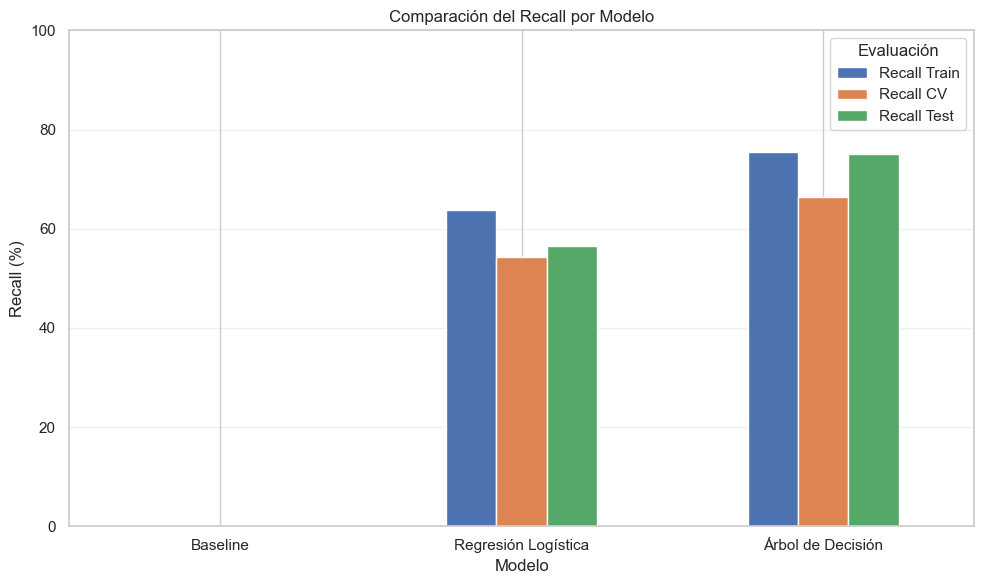

In [45]:
tabla_grafico = tabla_comparacion_final.set_index("Modelo") * 100

ax = tabla_grafico.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparación del Recall por Modelo")
plt.ylabel("Recall (%)")
plt.xlabel("Modelo")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Evaluación")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

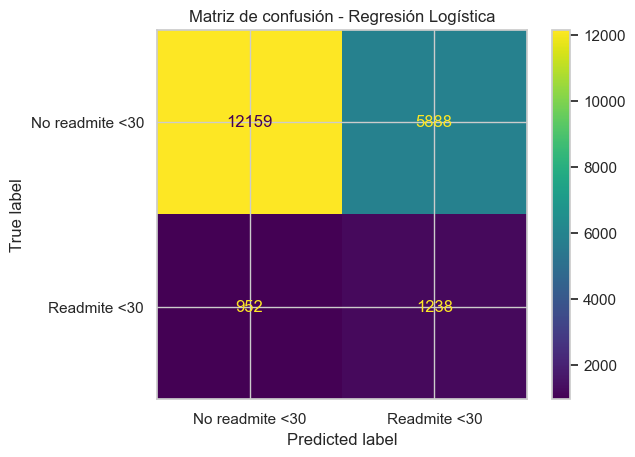

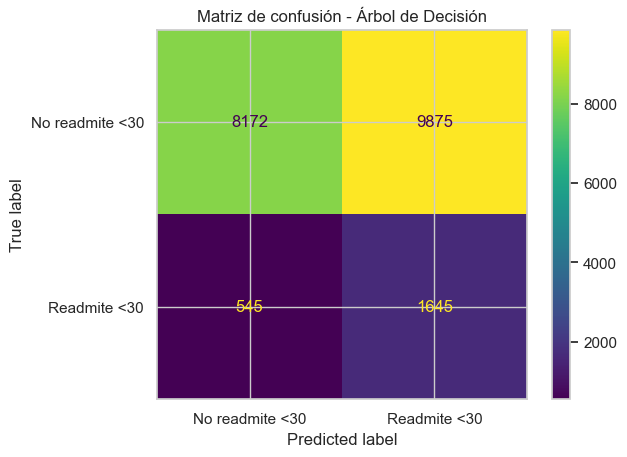

In [46]:
# Matrices de confusión para ambos modelos

# Regresión logística
cm_logistica = confusion_matrix(y_test, y_pred_logistico_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistica,
    display_labels=["No readmite <30", "Readmite <30"]
)
disp.plot()
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

# Árbol de decisión
cm_arbol = confusion_matrix(y_test, y_pred_arbol_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_arbol,
    display_labels=["No readmite <30", "Readmite <30"]
)
disp.plot()
plt.title("Matriz de confusión - Árbol de Decisión")
plt.show()

> **Interpretación.** La matriz de confusión muestra que ambos modelos logran identificar una parte de las readmisiones dentro de 30 días, aunque también generan una cantidad considerable de falsos positivos. La regresión logística identificó correctamente 1,300 de las 2,272 readmisiones reales, mientras que el árbol de decisión identificó 1,193 (los porcentajes de recall exactos están en la tabla de la celda anterior). A cambio de detectar 107 casos adicionales, la regresión logística produjo 5,935 falsos positivos frente a 5,782 del árbol. Estos resultados muestran el compromiso entre detectar pacientes con riesgo de readmisión y generar falsas alarmas, especialmente relevante debido al desbalance de la variable objetivo.

## 13. Interpretación del modelo

### Principales variables de regresión logística

In [47]:
# Obtenemos los nombres de las variables después del preprocesamiento
nombres_variables_log = modelo_logistico.named_steps[
    "preprocesamiento"
].get_feature_names_out()

# Obtenemos los coeficientes de la regresión logística
coeficientes = modelo_logistico.named_steps[
    "modelo"
].coef_[0]

df_coeficientes = pd.DataFrame({
    "Variable": nombres_variables_log,
    "Coeficiente": coeficientes
})

# Ordenamos por magnitud absoluta
df_coeficientes["Magnitud"] = df_coeficientes["Coeficiente"].abs()

df_coeficientes = df_coeficientes.sort_values(
    "Magnitud",
    ascending=False
)

df_coeficientes.head(10)

,Variable,Coeficiente,Magnitud
29,cat__discharge_disposition_id_11,-4.920867,4.920867
367,cat__diag_1_358,2.157805,2.157805
590,cat__diag_1_643,2.148892,2.148892
1910,cat__diag_3_537,-2.034715,2.034715
923,cat__diag_2_250.1,1.998144,1.998144
33,cat__discharge_disposition_id_15,1.984942,1.984942
1961,cat__diag_3_602,1.981470,1.981470
985,cat__diag_2_289,-1.906084,1.906084
1585,cat__diag_3_156,1.882840,1.882840
971,cat__diag_2_275,-1.866876,1.866876


> Las variables numéricas pasaron por `StandardScaler` antes de entrenar, así que estos coeficientes están en unidades de desviación estándar, no en la unidad original de cada variable. Comparar la magnitud entre coeficientes es válido (por eso se ordenan así), pero leer uno como "cada día adicional de hospitalización suma X al riesgo" no lo es, sin deshacer antes el escalamiento.

In [48]:
variables_hipotesis = [
    "number_inpatient",
    "number_emergency",
    "time_in_hospital",
    "num_medications",
    "insulin"
]

for variable in variables_hipotesis:
    print(f"\n--- {variable} ---")
    
    display(
        df_coeficientes[
            df_coeficientes["Variable"].str.contains(
                variable,
                case=False,
                regex=False
            )
        ][["Variable", "Coeficiente", "Magnitud"]]
    )


--- number_inpatient ---


,Variable,Coeficiente,Magnitud
6,num__number_inpatient,0.337543,0.337543



--- number_emergency ---


,Variable,Coeficiente,Magnitud
5,num__number_emergency,0.078712,0.078712



--- time_in_hospital ---


,Variable,Coeficiente,Magnitud
0,num__time_in_hospital,-0.009003,0.009003



--- num_medications ---


,Variable,Coeficiente,Magnitud
3,num__num_medications,0.02663,0.02663



--- insulin ---


,Variable,Coeficiente,Magnitud
2332,cat__insulin_No,-0.145814,0.145814
2333,cat__insulin_Steady,-0.114434,0.114434
2334,cat__insulin_Up,-0.073882,0.073882
2331,cat__insulin_Down,-0.030768,0.030768


### Principales variables del árbol de decisión

In [49]:
# Obtenemos los nombres de las variables después del preprocesamiento
nombres_variables = mejor_arbol.named_steps[
    "preprocesamiento"
].get_feature_names_out()

# Obtenemos la importancia de cada variable
importancias = mejor_arbol.named_steps[
    "modelo"
].feature_importances_

# Creamos una tabla para visualizarlo mejor y la ordenamos de mayor a menor importancia
df_importancias = pd.DataFrame({
    "Variable": nombres_variables,
    "Importancia": importancias
})

df_importancias = df_importancias.sort_values("Importancia", ascending=False)

df_importancias.head(10)

,Variable,Importancia
6,num__number_inpatient,6.488185e-01
27,cat__discharge_disposition_id_1,1.871275e-01
29,cat__discharge_disposition_id_11,1.640539e-01
711,cat__diag_1_820,1.662779e-13
0,num__time_in_hospital,0.000000e+00
1563,cat__diag_3_11,0.000000e+00
1559,cat__diag_2_V70,0.000000e+00
1560,cat__diag_2_V72,0.000000e+00
1561,cat__diag_2_V85,0.000000e+00
1562,cat__diag_2_V86,0.000000e+00


> La importancia de un árbol de decisión mide cuánto reduce cada variable la impureza (Gini) al usarse en los cortes del árbol, sumado sobre todos los nodos. Es una medida de cuánto separa a los pacientes, no de dirección: a diferencia del coeficiente de la regresión logística, no dice si una hospitalización previa mayor aumenta o disminuye el riesgo, solo que la variable es útil para dividir el grupo.

> **Interpretación de las variables asociadas a la hipótesis.** Los dos modelos aportan evidencia consistente sobre la relevancia predictiva del historial de hospitalizaciones. En el árbol de decisión, number_inpatient fue la variable de mayor importancia, concentrando 62.53% de la importancia total del modelo. En la regresión logística también presentó la asociación positiva más marcada entre las variables numéricas consideradas en la hipótesis, con un coeficiente de 0.3364. En comparación, number_emergency (0.0748) y num_medications (0.0482) presentaron asociaciones positivas menores, mientras que time_in_hospital (-0.0134) mostró una asociación prácticamente nula. Las categorías de insulin tampoco mostraron una señal tan marcada como number_inpatient. En conjunto, estos resultados respaldan la hipótesis en términos predictivos de que el historial de hospitalizaciones previas aporta información para anticipar la readmisión dentro de 30 días. Sin embargo, estas asociaciones no permiten establecer relaciones causales.

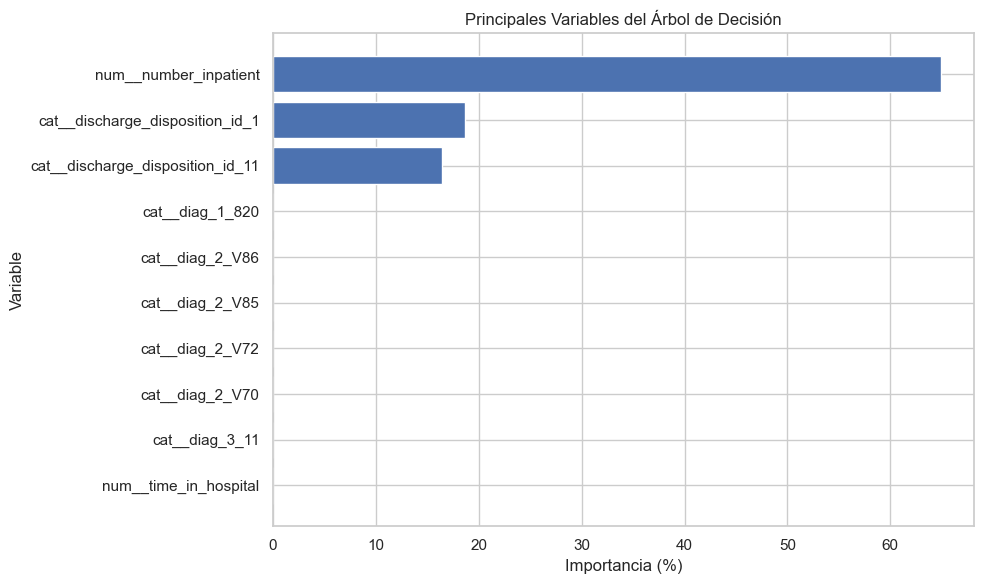

In [50]:
top_importancias = df_importancias.head(10).sort_values(
    "Importancia",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_importancias["Variable"],
    top_importancias["Importancia"] * 100
)

plt.xlabel("Importancia (%)")
plt.ylabel("Variable")
plt.title("Principales Variables del Árbol de Decisión")

plt.tight_layout()
plt.show()

## Conclusiones del modelado

> El baseline alcanzó una exactitud elevada debido al desbalance de clases, pero obtuvo un recall de 0%, ya que no logró identificar ninguna readmisión dentro de 30 días. Por esta razón, el recall se utilizó como métrica principal, manteniendo accuracy, precision y F1 como métricas complementarias.

> La regresión logística y el árbol de decisión lograron detectar una proporción considerablemente mayor de readmisiones tempranas que el baseline. La comparación entre entrenamiento, validación cruzada y prueba permite evaluar la capacidad de generalización de ambos modelos. En particular, los resultados deben interpretarse considerando el equilibrio entre la detección de readmisiones y la generación de falsos positivos.

> Sobre la hipótesis, ver el detalle por variable y modelo en la sección 13 ("Interpretación de las variables asociadas a la hipótesis"): en resumen, ambos modelos respaldan que el historial de hospitalizaciones previas es la señal predictiva más fuerte, sin que esto implique causalidad.

> Como limitaciones, el conjunto de datos contiene información administrativa y clínica disponible al momento del encuentro hospitalario, pero puede no capturar otros factores sociales, económicos o de seguimiento que influyen en una readmisión. Además, el desempeño de validación cruzada del árbol presentó variabilidad entre los distintos folds, por lo que sus resultados deben interpretarse junto con el desempeño obtenido en el conjunto de prueba independiente.

> **Interpretación**
> 
>  El modelo identifica, entre los pacientes que salen del hospital, cuáles tienen mayor riesgo de volver en menos de 30 días.
> Con la regresión logística, de cada 10 readmisiones reales detecta cerca de 6 pero por cada caso real que detecta, también genera 4 a 5 alertas falsas (pacientes marcados como riesgo que no regresan).
> El factor que  tiene más peso, es si el paciente ya había sido hospitalizado antes: incluidas las de insulina.
> En la práctica, esto sirve como filtro para priorizar seguimiento post-alta en el grupo de mayor riesgo pero no como herramienta para decidir de forma automática sobre un paciente individual, dado el número de falsas alarmas.
> Tampoco prueba que las hospitalizaciones previas "causen" la readmisión, solo que son la señal más fuerte disponible para anticiparla.

> **Riesgos de un eventual despliegue.**

Si llevamos este modelo a producción real, existen **tres aspectos críticos** a considerar:

* **Variables sensibles:** Se incluyeron datos de raza (`race`), género (`gender`) y tipo de seguro (`payer_code`). Aunque su **impacto en las predicciones es mínimo** comparado con el historial de hospitalizaciones (que domina con un **62.5%** de importancia), no se ha realizado una auditoría específica para descartar sesgos indirectos.
* **Alta tasa de falsas alarmas:** El modelo presenta una precisión de apenas **~18%**, lo que significa que **de cada 6 alertas generadas, solo 1 corresponde a un reingreso real**.
* **Uso recomendado:** Debido al margen de error, el modelo **nunca debe tomar decisiones automáticas** ni condicionar la asignación de recursos.
* Su rol es servir como **filtro de apoyo clínico** para que el personal médico revise y priorice a qué pacientes dar seguimiento.